# Cleaning of data and comparing peak and peak off time

In [1]:
import numpy as np

In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv("last_mile_delivery_dataset.csv")

In [4]:
df

,order_id,order_date,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,delivery_status,weather_condition,order_value_inr,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude
0,ORD000001,2024-09-02,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,-2.6,On-Time,Partly Cloudy,377.96,1,7.9,4.6,28.9867,87.3825
1,ORD000002,2024-09-13,14:53,Delhi,East,RID0100,cycle,Electronics,14.75,30,29.7,-0.3,On-Time,Clear,1352.80,1,0.4,4.5,36.7618,84.6386
2,ORD000003,2024-02-28,18:01,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,27.0,Delayed,Clear,1302.15,2,7.8,3.4,NaN,NaN
3,ORD000004,2024-07-13,14:59,Chennai,North,RID0050,AUTO,Documents,10.27,30,57.2,27.2,Delayed,Rain,3308.73,1,6.8,4.4,17.7429,71.3316
4,ORD000005,2024-07-24,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,-4.5,On-Time,Partly Cloudy,3095.74,2,1.1,3.1,22.9501,96.4950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,ORD002076,2024-12-25,16:45,Kolkata,East,RID0148,Cycle,Grocery,15.77,120,113.9,-6.1,On-Time,Clear,2416.41,1,6.6,3.9,25.0939,88.5686
2076,ORD002077,2024-04-03,17:44,Hydrabad,Central,RID0033,cycle,Apparel,420.38,45,45.0,0.0,On-Time,Partly Cloudy,4971.55,1,0.3,3.9,35.3348,89.2757
2077,ORD002078,2024-10-20,14:54,Jaipur,South,RID0119,Bike,Medicine,16.34,60,55.1,-4.9,On-Time,Partly Cloudy,288.60,1,3.2,4.8,27.7116,89.5957
2078,ORD002079,2024-10-20,19:52,Kolkata,West,RID0144,Auto,Food,10.19,90,93.9,3.9,On-Time,Clear,2488.03,1,0.7,3.7,20.8429,87.3996


In [5]:
print("Raw shape: ",df.shape)

Raw shape:  (2080, 20)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                2080 non-null   object 
 1   order_date              2080 non-null   object 
 2   order_time              2080 non-null   object 
 3   city                    2080 non-null   object 
 4   zone                    1944 non-null   object 
 5   rider_id                1967 non-null   object 
 6   vehicle_type            2080 non-null   object 
 7   order_type              2080 non-null   object 
 8   distance_km             2080 non-null   float64
 9   promised_delivery_mins  2080 non-null   int64  
 10  actual_delivery_mins    2080 non-null   object 
 11  delay_mins              2080 non-null   float64
 12  delivery_status         2080 non-null   object 
 13  weather_condition       2080 non-null   object 
 14  order_value_inr         2080 non-null   

In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [8]:
df = df.drop_duplicates()

In [9]:
df["city"] = df["city"].astype(str).str.strip().str.title()
df["city"] = df["city"].replace({"Bangaluru": "Bangalore", "Hydrabad": "Hyderabad"})

In [10]:
df["vehicle_type"] = df["vehicle_type"].astype(str).str.strip().str.title()
df["order_type"] = df["order_type"].astype(str).str.strip().str.title()
df["weather_condition"] = df["weather_condition"].astype(str).str.strip().str.title()

In [11]:
df["actual_delivery_mins"] = (
    df["actual_delivery_mins"].astype(str).str.replace(" mins", "", regex=False).str.strip())
df["actual_delivery_mins"] = pd.to_numeric(df["actual_delivery_mins"], errors="coerce")

In [12]:
df["delay_mins"] = pd.to_numeric(df["delay_mins"], errors="coerce")
df = df.dropna(subset=["delay_mins"])

In [13]:
df["order_datetime"] = pd.to_datetime(
    df["order_date"].astype(str) + " " + df["order_time"].astype(str), errors="coerce")
df = df.dropna(subset=["order_datetime"])

In [14]:
df

,order_id,order_date,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,...,delay_mins,delivery_status,weather_condition,order_value_inr,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_datetime
0,ORD000001,2024-09-02,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,...,-2.6,On-Time,Partly Cloudy,377.96,1,7.9,4.6,28.9867,87.3825,2024-09-02 13:10:00
1,ORD000002,2024-09-13,14:53,Delhi,East,RID0100,Cycle,Electronics,14.75,30,...,-0.3,On-Time,Clear,1352.80,1,0.4,4.5,36.7618,84.6386,2024-09-13 14:53:00
2,ORD000003,2024-02-28,18:01,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,...,27.0,Delayed,Clear,1302.15,2,7.8,3.4,NaN,NaN,2024-02-28 18:01:00
3,ORD000004,2024-07-13,14:59,Chennai,North,RID0050,Auto,Documents,10.27,30,...,27.2,Delayed,Rain,3308.73,1,6.8,4.4,17.7429,71.3316,2024-07-13 14:59:00
4,ORD000005,2024-07-24,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,...,-4.5,On-Time,Partly Cloudy,3095.74,2,1.1,3.1,22.9501,96.4950,2024-07-24 14:28:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,ORD002076,2024-12-25,16:45,Kolkata,East,RID0148,Cycle,Grocery,15.77,120,...,-6.1,On-Time,Clear,2416.41,1,6.6,3.9,25.0939,88.5686,2024-12-25 16:45:00
2076,ORD002077,2024-04-03,17:44,Hyderabad,Central,RID0033,Cycle,Apparel,420.38,45,...,0.0,On-Time,Partly Cloudy,4971.55,1,0.3,3.9,35.3348,89.2757,2024-04-03 17:44:00
2077,ORD002078,2024-10-20,14:54,Jaipur,South,RID0119,Bike,Medicine,16.34,60,...,-4.9,On-Time,Partly Cloudy,288.60,1,3.2,4.8,27.7116,89.5957,2024-10-20 14:54:00
2078,ORD002079,2024-10-20,19:52,Kolkata,West,RID0144,Auto,Food,10.19,90,...,3.9,On-Time,Clear,2488.03,1,0.7,3.7,20.8429,87.3996,2024-10-20 19:52:00


In [15]:
df["order_hour"] = df["order_datetime"].dt.hour
df["time_period"] = np.where(
    ((df["order_hour"] >= 8) & (df["order_hour"] < 10)) |
    ((df["order_hour"] >= 17) & (df["order_hour"] < 20)),
    "Peak", "Off-Peak")
df = df.reset_index(drop=True)

In [16]:
from scipy import stats

In [17]:
summary = df.groupby("time_period")["delay_mins"].agg(["mean", "median", "std", "count"])
print(summary)
peak = df[df["time_period"] == "Peak"]["delay_mins"]
off_peak = df[df["time_period"] == "Off-Peak"]["delay_mins"]
t_stat, p_val = stats.ttest_ind(peak, off_peak, equal_var=False)
print(f"t-stat: {t_stat:.3f}, p-value: {p_val:.5f}")
print(f"Mean difference (Peak - Off-Peak): {peak.mean() - off_peak.mean():.2f} mins")

                  mean  median        std  count
time_period                                     
Off-Peak      9.601874     7.2  21.123956   1441
Peak         23.948983    21.1  21.570563    639
t-stat: 14.083, p-value: 0.00000
Mean difference (Peak - Off-Peak): 14.35 mins


In [19]:
df.to_csv("cleaned_delivery_data.csv",index=False)

# EDA : Weather vs Delay Correlation 

In [20]:
df = pd.read_csv("cleaned_delivery_data.csv")

In [21]:
print("Median & Mean delay by weather_condition")

Median & Mean delay by weather_condition


In [26]:
weather_summary = (
    df.groupby("weather_condition")["delay_mins"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("median",ascending=False)
)

In [27]:
print(weather_summary)

                        mean  median        std  count
weather_condition                                     
Fog                39.620958    37.9  19.777689    167
Rain               31.323223    29.4  22.676144    422
Clear               6.462603     6.1  16.774370   1091
Partly Cloudy       5.634750     5.5  17.064140    400


**Rain only: delay by order_type**

In [28]:
rain_df = df[df["weather_condition"] == "Rain"]

In [29]:
rain_by_type = (
    rain_df.groupby("order_type")["delay_mins"]
    .agg(["mean", "median", "count"])
    .sort_values("median", ascending=False)
)

In [30]:
print(rain_by_type)

                  mean  median  count
order_type                           
Medicine     34.413636   34.65     66
Documents    30.385714   29.80     70
Food         32.437143   29.20     70
Grocery      28.265789   29.05     76
Electronics  30.666667   28.80     81
Apparel      32.496610   27.10     59


**Comparing Rain delay vs Overall all weather delay by orderType**

In [31]:
overall_by_type = df.groupby("order_type")["delay_mins"].median()

In [32]:
comp = pd.DataFrame({
    "rain_median": rain_by_type["median"],
    "overall_median": overall_by_type,
})

In [33]:
comp["extra_delay_in_rain"] = comp["rain_median"] - comp["overall_median"]
comp = comp.sort_values("extra_delay_in_rain", ascending=False)
print(comp)

             rain_median  overall_median  extra_delay_in_rain
order_type                                                   
Medicine           34.65           11.40                23.25
Apparel            27.10            9.20                17.90
Electronics        28.80           11.35                17.45
Grocery            29.05           11.90                17.15
Documents          29.80           12.80                17.00
Food               29.20           12.60                16.60


In [34]:
import matplotlib.pyplot as plt

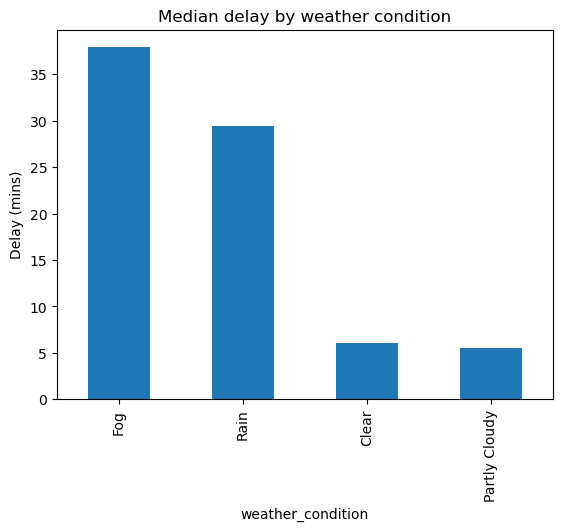

In [35]:
weather_summary["median"].plot(kind="bar")
plt.title("Median delay by weather condition")
plt.ylabel("Delay (mins)")
plt.show()

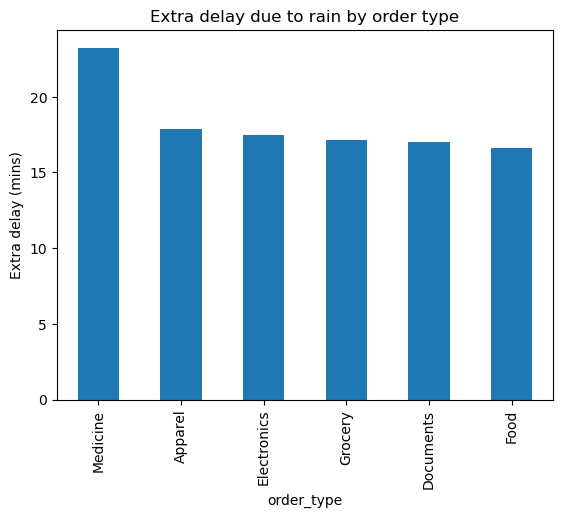

In [37]:
comp["extra_delay_in_rain"].plot(kind="bar")
plt.title("Extra delay due to rain by order type")
plt.ylabel("Extra delay (mins)")
plt.show()

# Rider Experience Effect Result

** grouping riders by experience

In [38]:
new_riders = df[df["rider_experience_yrs"] < 2]["delay_mins"]
exp_riders = df[df["rider_experience_yrs"] > 4]["delay_mins"]

In [43]:
print("New riders (<2 yrs):\n",new_riders.describe())
print("Experienced riders (>4 yrs):\n",exp_riders.describe())

New riders (<2 yrs):
 count    450.000000
mean      13.746000
std       22.707802
min      -44.100000
25%       -1.575000
50%       11.600000
75%       26.700000
max       88.100000
Name: delay_mins, dtype: float64
Experienced riders (>4 yrs):
 count    1065.000000
mean       14.348169
std        22.103956
min       -43.900000
25%        -0.700000
50%        12.200000
75%        26.700000
max       107.400000
Name: delay_mins, dtype: float64


In [44]:
print("New riders (<2 yrs):")
print("Mean delay:", new_riders.mean())
print("Median delay:", new_riders.median())
print("Count:", new_riders.count())
print("\nExperienced riders (>4 yrs):")
print("Mean delay:", exp_riders.mean())
print("Median delay:", exp_riders.median())
print("Count:", exp_riders.count())

New riders (<2 yrs):
Mean delay: 13.746000000000002
Median delay: 11.6
Count: 450

Experienced riders (>4 yrs):
Mean delay: 14.348169014084508
Median delay: 12.2
Count: 1065


In [45]:
df["order_datetime"] = pd.to_datetime(df["order_datetime"])
df["month"] = df["order_datetime"].dt.month

# Panel 1

In [46]:
city_status = df.groupby(["city", "delivery_status"]).size().unstack(fill_value=0)
city_status["total"] = city_status["On-Time"] + city_status["Delayed"]
city_status["on_time_rate"] = (city_status["On-Time"] / city_status["total"]) * 100
city_ontime = city_status["on_time_rate"].sort_values(ascending=False)

# Panel 2

In [47]:
monthly_delay = df.groupby("month")["delay_mins"].mean()

# Panel 3

In [48]:
vehicle_delay = df.groupby("vehicle_type")["delay_mins"].mean().sort_values(ascending=False)

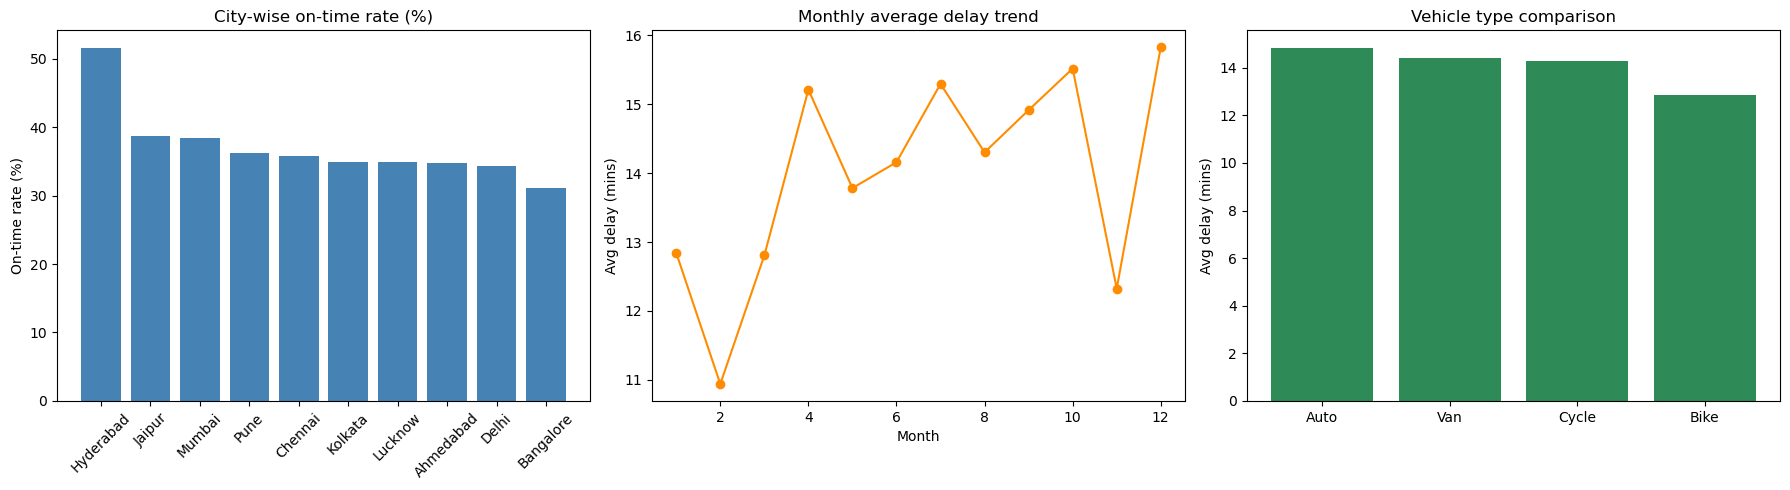

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(city_ontime.index, city_ontime.values, color="steelblue")
axes[0].set_title("City-wise on-time rate (%)")
axes[0].set_ylabel("On-time rate (%)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_delay.index, monthly_delay.values, marker="o", color="darkorange")
axes[1].set_title("Monthly average delay trend")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg delay (mins)")

axes[2].bar(vehicle_delay.index, vehicle_delay.values, color="seagreen")
axes[2].set_title("Vehicle type comparison")
axes[2].set_ylabel("Avg delay (mins)")

plt.tight_layout()
plt.savefig("city_performance_dashboard.png", dpi=150)
plt.show()